<a href="https://colab.research.google.com/github/san031/Machine_learning-Artificial-Intelligence-Projects/blob/main/deep_learning/Convolutional_Neural_Network/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
(X_train,y_train), (X_test,y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train[0][9]

array([  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
       205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0], dtype=uint8)

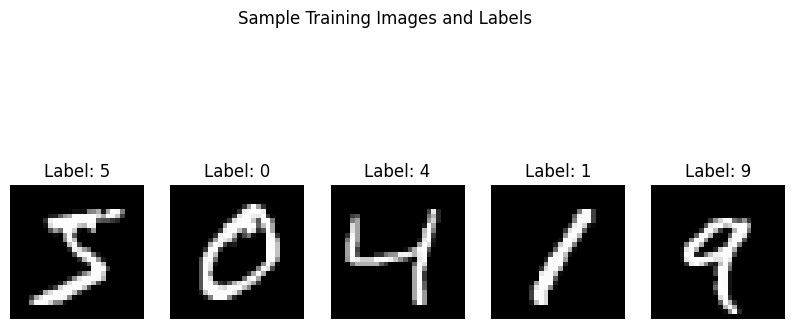

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Squeeze the channel dimension for grayscale image display
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.suptitle('Sample Training Images and Labels')
plt.show()

In [ ]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [ ]:
# normalize the pixel value
X_train = X_train/255.0

In [ ]:
X_test = X_test/255.0

## Adding a channel dimension

In [ ]:
X_train = X_train.reshape((X_train.shape[0],28,28,1))

In [ ]:
X_test = X_test.reshape((X_test.shape[0],28,28,1))

In [ ]:
# X_train = X_test[...,None] # This line incorrectly overwrote X_train, it has been commented out

In [ ]:
X_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

####  CNN Model; layers -> cnn, dense -> ann

In [ ]:
model = models.Sequential([
      layers.Conv2D(32, (3,3), activation='relu', input_shape = (28,28,1)),

      layers.MaxPooling2D((2,2)),

      layers.Conv2D(64, (3,3), activation='relu'),

      layers.MaxPooling2D((2,2)),

      layers.Flatten(),

      layers.Dense(128, activation="relu"),

      layers.Dense(10, activation='softmax')
  ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train,y_train,epochs = 100, validation_split=0.1)

Epoch 1/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9994 - loss: 0.0034 - val_accuracy: 0.9922 - val_loss: 0.0910
Epoch 2/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9992 - loss: 0.0033 - val_accuracy: 0.9915 - val_loss: 0.0868
Epoch 3/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9998 - loss: 7.7393e-04 - val_accuracy: 0.9915 - val_loss: 0.0891
Epoch 4/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9915 - val_loss: 0.1046
Epoch 5/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9992 - loss: 0.0038 - val_accuracy: 0.9930 - val_loss: 0.0895
Epoch 6/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9998 - loss: 6.2789e-04 - val_accuracy: 0.9917 - val_loss: 0.1018
Epoch 7/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9920 - val_loss: 0.0957
Epoch 8/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9994 

In [ ]:
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
X_test = X_test.astype('float32') / 255.0

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=2)

313/313 - 1s - 2ms/step - accuracy: 0.0974 - loss: 2.3687


## predicting new image

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
#test_image = image.load_img('/content/sample_data/cnn_digit_prediction.jpg',target_size=(64,64))
test_image = image.load_img(
    '/content/sample_data/predict8.jpg',
    target_size=(28, 28),
    color_mode='grayscale'
)


In [ ]:
test_image

In [ ]:
img_array = image.img_to_array(test_image)   # shape (1,28,28,1)

In [ ]:
img_array = 255 - img_array

In [ ]:
img_array = img_array / 255.0
img_input = img_array.reshape(1, 28, 28, 1)

In [ ]:

img_input = img_array.reshape(1, 28, 28, 1)
pred = model.predict(img_input)
predicted_digit = np.argmax(pred)
print("Predicted digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted digit: 3


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

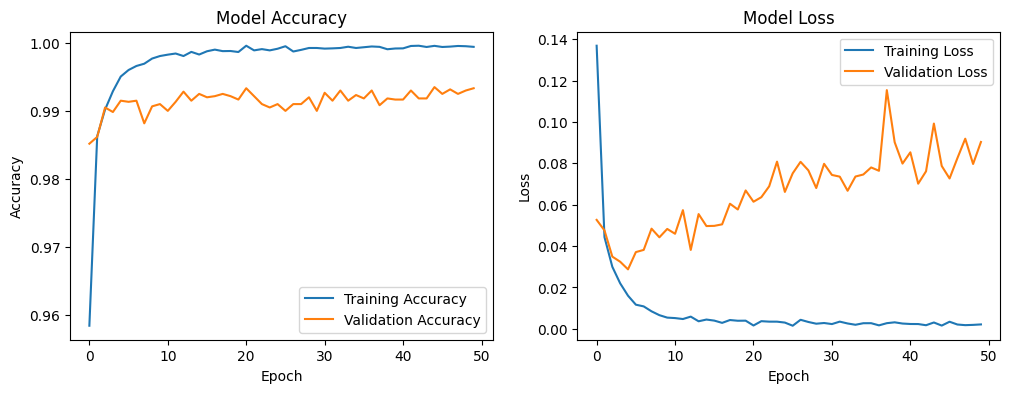

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

In [ ]:
test_image = image.load_img(
    '/content/sample_data/predict8.jpg',
    target_size=(28, 28),
    color_mode='grayscale'
)

In [ ]:
print("Predicted digit:", predicted_labels)

Predicted digit: [1 1 1 ... 1 1 1]
